In [18]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [19]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns',100)

In [20]:
from google.colab import files

uploaded = files.upload()

Saving Country-data.csv to Country-data (2).csv


In [21]:
csv_name = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [22]:
print("Shape:",df.shape)

df.head()
df.info()
df.describe()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [23]:
df.columns = [c.strip().lower() for c in df.columns]

df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


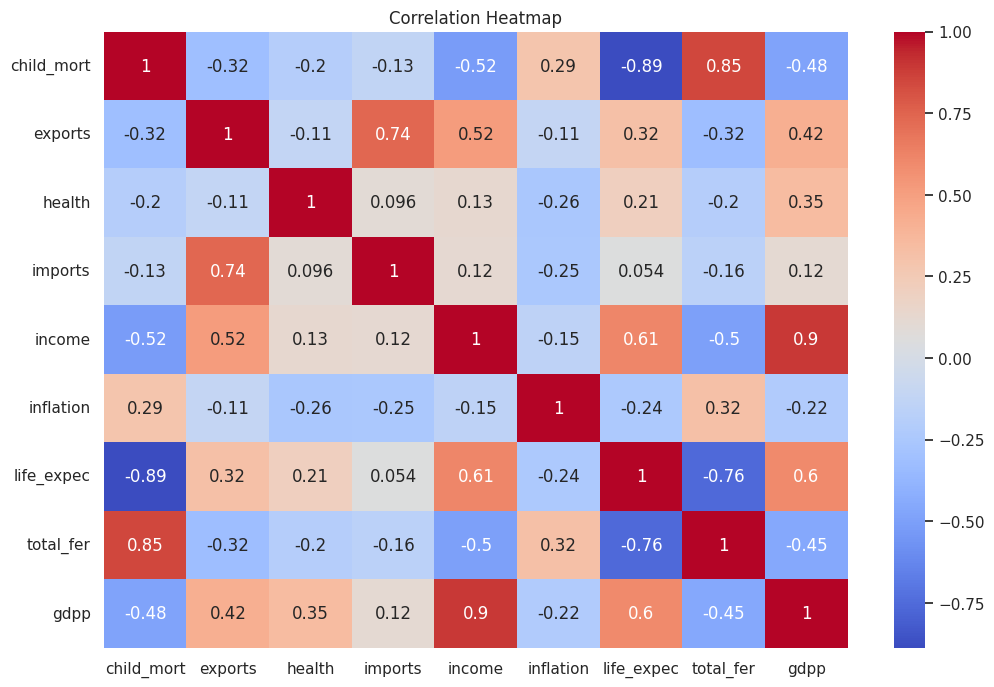

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:**

Income and GDP are strongly positively correlated.
Child mortality has a negative relationship with life expectancy.

In [25]:
features = df.drop(
    columns=['country'],
    errors='ignore'
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

X_scaled.shape

(167, 9)

In [26]:
inertias = []

k_values = range(2,11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

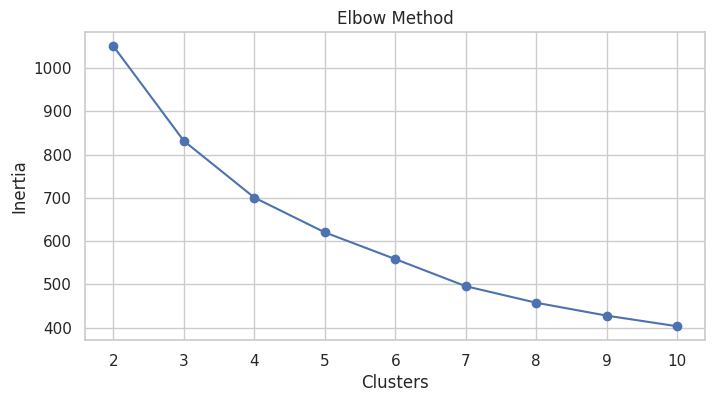

In [27]:
plt.figure(figsize=(8,4))

plt.plot(
    list(k_values),
    inertias,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.show()

In [28]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(
    "Silhouette Score:",
    silhouette_score(
        X_scaled,
        df['kmeans_cluster']
    )
)

Silhouette Score: 0.28329575683463126


In [29]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['dbscan_cluster'] = dbscan.fit_predict(
    X_scaled
)

df['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
0,137
-1,30


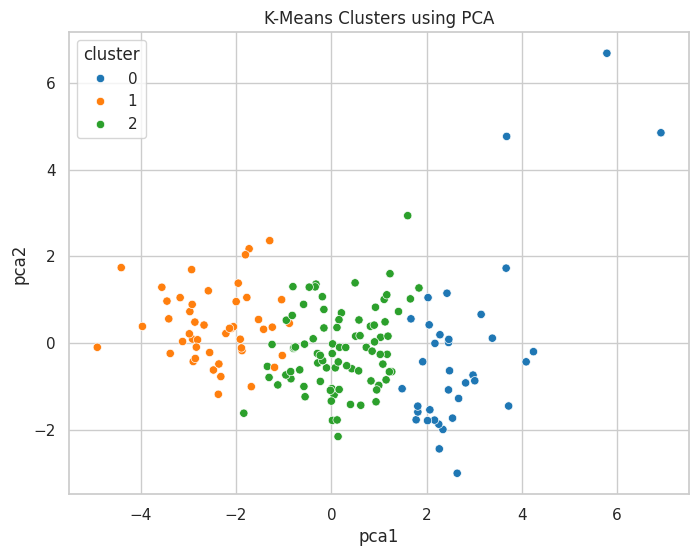

In [30]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1':X_pca[:,0],
    'pca2':X_pca[:,1],
    'cluster':df['kmeans_cluster']
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=viz,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='tab10'
)

plt.title(
    "K-Means Clusters using PCA"
)

plt.show()

In [31]:
profile = df.groupby(
    'kmeans_cluster'
)[numeric_cols].mean().round(2)

profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


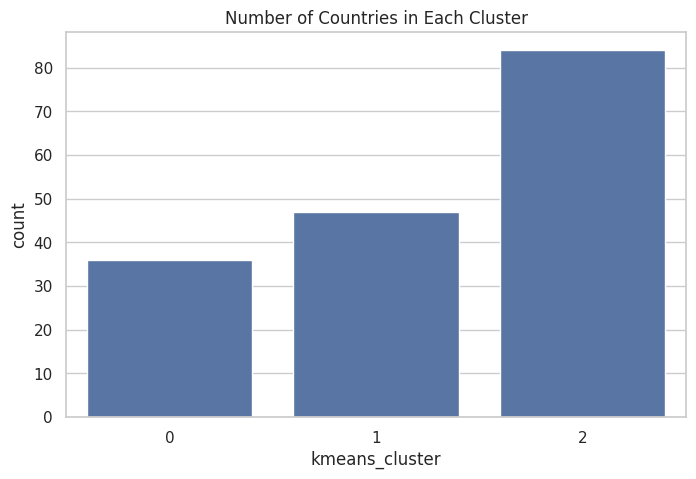

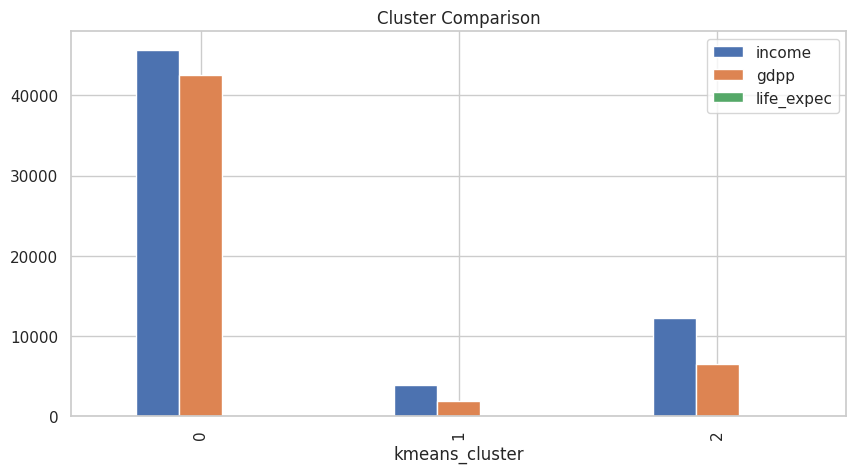

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='kmeans_cluster', data=df)
plt.title('Number of Countries in Each Cluster')
plt.show()

df.groupby('kmeans_cluster')[['income','gdpp','life_expec']].mean().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Cluster Comparison')
plt.show()

# Final Insights

1. K-Means clustering successfully segmented countries into three meaningful groups: Developed, Developing, and Underdeveloped.

2. Cluster 0 contains economically strong countries with high income levels, high GDP per capita, low child mortality, and high life expectancy.

3. Cluster 1 represents the most vulnerable countries, characterized by low income, low GDP per capita, high child mortality, and lower life expectancy.

4. Cluster 2 consists of developing countries with moderate economic and health indicators and significant growth potential.

5. Income, GDP per capita, child mortality, and life expectancy were the most influential factors in determining country clusters.

6. Countries in Cluster 1 should be prioritized for international aid, healthcare improvements, and economic development initiatives.

# Conclusion

This project applied unsupervised learning techniques to segment countries based on socioeconomic and health indicators.

The Elbow Method identified an optimal number of clusters, and K-Means clustering grouped countries into three distinct categories: Developed, Developing, and Underdeveloped.

PCA visualization confirmed clear separation among clusters, while cluster profiling provided valuable insights into economic and healthcare conditions across countries.

These findings can assist governments, NGOs, policymakers, and international organizations in identifying countries that require targeted support and strategic investment.

Future work may include Hierarchical Clustering, advanced dimensionality reduction techniques, and additional socioeconomic indicators to improve segmentation accuracy.